<a href="https://colab.research.google.com/github/vaidiknakrani/parul_AI_ML_Learning/blob/main/day_3_telecom_customer_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 3 - Notebook 2: Telecom Customer Churn Prediction
## Naive Bayes & Comparison with Logistic Regression

**Parul University & TelcoLearn | AI-ML Training Program 2027**  
**Day 3 | July 15, 2025 | 1:00 PM - 2:30 PM**

---

## Objective
Predict which telecom customers will churn (cancel their subscription).
We use this dataset because it is **genuinely raw** -- it has dtype issues,
hidden missing values, and mixed feature types that need real preprocessing.

| Step | What you do | What you learn |
|------|-------------|----------------|
| 1 | Load raw data | Discover hidden data quality issues |
| 2 | Fix dtype bug | TotalCharges stored as string, not float |
| 3 | Encode categoricals | LabelEncoder for NB, many columns |
| 4 | Train GaussianNB | Probability estimation per class |
| 5 | Train MultinomialNB | Requires non-negative features |
| 6 | Compare NB with LR | Is NB competitive despite naive assumption? |
| 7 | Threshold tuning | Find optimal threshold for churn detection |
| 8 | Feature analysis | What features NB finds most discriminative |

**Dataset:** Telco Customer Churn (IBM)  
**Kaggle path:** `/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv`  
**Dataset URL:** https://www.kaggle.com/datasets/blastchar/telco-customer-churn  
**Task:** Binary classification - predict `Churn` (Yes/No)  

---
> **Why Naive Bayes on churn data?** NB is blazing fast and works well on
> mixed categorical/numeric features. On telecom churn, it often gets surprisingly
> close to Logistic Regression despite the 'naive' independence assumption.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import time
import psutil
import pickle

process = psutil.Process(os.getpid())
warnings.filterwarnings('ignore')

from sklearn.naive_bayes     import GaussianNB, MultinomialNB
from sklearn.linear_model    import LogisticRegression
from sklearn.preprocessing   import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics         import (accuracy_score, f1_score, roc_auc_score,
                                      classification_report, confusion_matrix,
                                      ConfusionMatrixDisplay, roc_curve,
                                      precision_score, recall_score)

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid', palette='muted')
print('All imports successful.')

All imports successful.


In [ ]:
DATASET_PATH = '/kaggle/input/datasets/blastchar/telco-customer-churn'
# DATASET_PATH = '.'  # uncomment for local run

df_raw = pd.read_csv(f'{DATASET_PATH}/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'Shape: {df_raw.shape}')
print(f'\nColumn dtypes:')
print(df_raw.dtypes.to_string())
print(f'\nMissing values (NaN): {df_raw.isnull().sum().sum()}')

Shape: (7043, 21)

Column dtypes:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object

Missing values (NaN): 0


## Section 2 - Data Cleaning (The Raw Part)

This dataset has a subtle but critical issue: `TotalCharges` is stored
as `object` (string) instead of `float`. This is because some rows contain
a whitespace string `' '` instead of a number -- representing new customers
who have no total charges yet.

**This is a real-world data quality problem.** If you try to use TotalCharges
without fixing this, your model will crash or silently give wrong results.

In [ ]:
df = df_raw.copy()

# BUG 1: TotalCharges is object (string), should be float
print('TotalCharges dtype before fix:', df['TotalCharges'].dtype)
print('Sample values:', df['TotalCharges'].head(10).tolist())

# Find the problematic rows (whitespace strings)
problem_rows = df[df['TotalCharges'].str.strip() == '']
print(f'\nRows with whitespace TotalCharges: {len(problem_rows)}')
print(problem_rows[['tenure','MonthlyCharges','TotalCharges','Churn']])

# Fix: convert to float, whitespace becomes NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'\nAfter fix - TotalCharges dtype: {df["TotalCharges"].dtype}')
print(f'NaN count: {df["TotalCharges"].isnull().sum()}')

# These customers have tenure=0, so TotalCharges=0 makes sense
df['TotalCharges'].fillna(0.0, inplace=True)
print('Filled NaN with 0 (new customers, no charges yet). Final NaN count:',
      df['TotalCharges'].isnull().sum())

TotalCharges dtype before fix: object
Sample values: ['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5', '1949.4', '301.9', '3046.05', '3487.95']

Rows with whitespace TotalCharges: 11
      tenure  MonthlyCharges TotalCharges Churn
488        0           52.55                 No
753        0           20.25                 No
936        0           80.85                 No
1082       0           25.75                 No
1340       0           56.05                 No
3331       0           19.85                 No
3826       0           25.35                 No
4380       0           20.00                 No
5218       0           19.70                 No
6670       0           73.35                 No
6754       0           61.90                 No

After fix - TotalCharges dtype: float64
NaN count: 11
Filled NaN with 0 (new customers, no charges yet). Final NaN count: 0


In [ ]:
# BUG 2: SeniorCitizen is 0/1 integer but all other categoricals are Yes/No strings
# Standardise for consistency
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: 'Yes', 0: 'No'})

# Drop CustomerID (just an identifier)
df.drop(columns=['customerID'], inplace=True)

# Binary target
df['ChurnBinary'] = (df['Churn'] == 'Yes').astype(int)
df.drop(columns=['Churn'], inplace=True)

print(f'Churn rate: {df["ChurnBinary"].mean()*100:.1f}%')
print(f'\nCategorical columns:')
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(cat_cols)
print(f'\nNumeric columns:')
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('ChurnBinary')
print(num_cols)

Churn rate: 26.5%

Categorical columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numeric columns:
['tenure', 'MonthlyCharges', 'TotalCharges']


In [ ]:
# Encode all categorical columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

TARGET   = 'ChurnBinary'
FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# GaussianNB: needs StandardScaler
ss = StandardScaler()
X_tr_s  = ss.fit_transform(X_train)
X_val_s = ss.transform(X_val)

# MultinomialNB: needs non-negative features -- use MinMaxScaler
mm = MinMaxScaler()
X_tr_mm  = mm.fit_transform(X_train)
X_val_mm = mm.transform(X_val)

print(f'Train:{X_train.shape[0]}  Val:{X_val.shape[0]}  Test:{X_test.shape[0]}')
print(f'Churn rate: Train={y_train.mean()*100:.1f}%  Val={y_val.mean()*100:.1f}%')

Train:4507  Val:1127  Test:1409
Churn rate: Train=26.5%  Val=26.5%


## Section 3 - Gaussian Naive Bayes

GaussianNB assumes each feature follows a **Gaussian (normal) distribution** per class.
For each feature j and class k, it learns:
- Mean: mu_jk = average of feature j among all training examples with class k
- Variance: sigma_jk^2 = variance of feature j within class k

At prediction time: P(x|y=k) = product of N(x_j; mu_jk, sigma_jk) across all j.

The **naive** part: it assumes features are independent given the class.
Contract type and monthly charges are NOT independent in reality -- but NB often
works well anyway because we only need the right ranking of class probabilities.

In [ ]:
training_start = time.time()

gnb = GaussianNB()
gnb.fit(X_tr_s, y_train)

training_end = time.time()
gnb_training_time = training_end - training_start

cpu_after = psutil.cpu_percent(interval=1)
memory_after = process.memory_info().rss / (1024**2)

prediction_start = time.time()

preds_gnb = gnb.predict(X_val_s)
probs_gnb = gnb.predict_proba(X_val_s)[:,1]

prediction_end = time.time()
gnb_prediction_time = prediction_end - prediction_start

with open("gnb.pkl", "wb") as f:
    pickle.dump(gnb, f)

gnb_model_size = os.path.getsize("gnb.pkl") / (1024**2)

print("GaussianNB Results:")
print(f"Accuracy : {accuracy_score(y_val,preds_gnb):.4f}")
print(f"F1 Score : {f1_score(y_val,preds_gnb):.4f}")
print(f"AUC      : {roc_auc_score(y_val,probs_gnb):.4f}")

print(f"Training Time   : {gnb_training_time:.4f} sec")
print(f"Prediction Time : {gnb_prediction_time:.6f} sec")
print(f"CPU Usage       : {cpu_after:.2f}%")
print(f"Memory Usage    : {memory_after:.2f} MB")
print(f"Model Size      : {gnb_model_size:.6f} MB")

GaussianNB Results:
Accuracy : 0.7551
F1 Score : 0.6124
AUC      : 0.8206
Training Time   : 0.0062 sec
Prediction Time : 0.002177 sec
CPU Usage       : 0.70%
Memory Usage    : 269.34 MB
Model Size      : 0.001137 MB


In [ ]:
training_start = time.time()

mnb = MultinomialNB(alpha=1.0)
mnb.fit(X_tr_mm, y_train)

training_end = time.time()
mnb_training_time = training_end - training_start

cpu_after = psutil.cpu_percent(interval=1)
memory_after = process.memory_info().rss / (1024**2)

prediction_start = time.time()

preds_mnb = mnb.predict(X_val_mm)
probs_mnb = mnb.predict_proba(X_val_mm)[:,1]

prediction_end = time.time()
mnb_prediction_time = prediction_end - prediction_start

with open("mnb.pkl","wb") as f:
    pickle.dump(mnb,f)

mnb_model_size = os.path.getsize("mnb.pkl")/(1024**2)

training_start = time.time()

lr = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42
)

lr.fit(X_tr_s, y_train)

training_end = time.time()
lr_training_time = training_end - training_start

prediction_start = time.time()

preds_lr = lr.predict(X_val_s)
probs_lr = lr.predict_proba(X_val_s)[:,1]

prediction_end = time.time()
lr_prediction_time = prediction_end - prediction_start

with open("lr.pkl","wb") as f:
    pickle.dump(lr,f)

lr_model_size = os.path.getsize("lr.pkl")/(1024**2)

all_results = {
    "GaussianNB":{"preds":preds_gnb,"probs":probs_gnb},
    "MultinomialNB":{"preds":preds_mnb,"probs":probs_mnb},
    "Logistic Regression":{"preds":preds_lr,"probs":probs_lr}
}

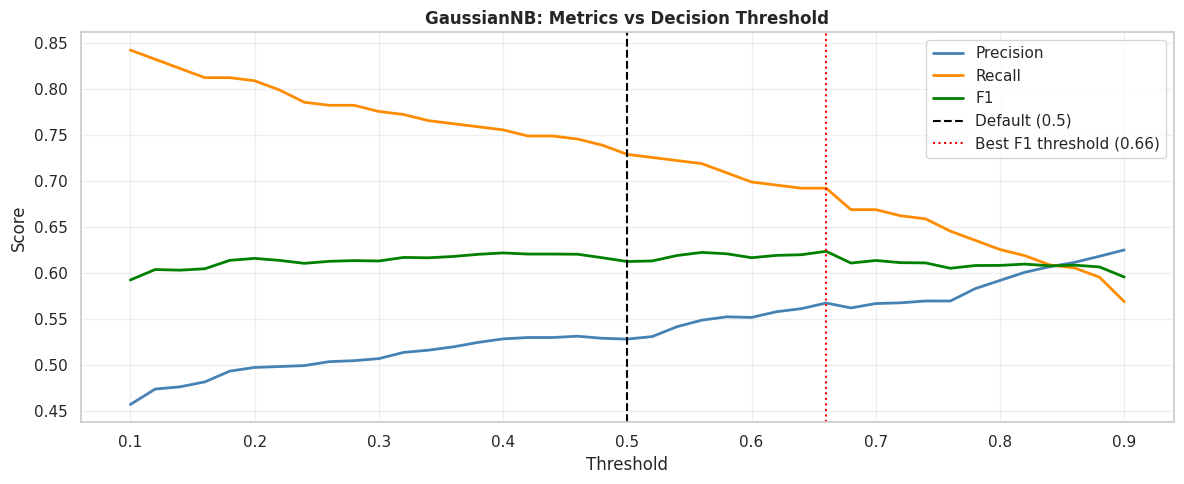

At default threshold 0.5:  F1=0.6124
At best threshold 0.66:   F1=0.6235


In [ ]:
# Threshold tuning for GaussianNB
thresholds = np.arange(0.1, 0.91, 0.02)
rows = []
for t in thresholds:
    preds_t = (probs_gnb >= t).astype(int)
    if 0 < preds_t.sum() < len(preds_t):
        rows.append({
            'threshold': t,
            'precision': precision_score(y_val, preds_t, zero_division=0),
            'recall'   : recall_score(y_val, preds_t, zero_division=0),
            'f1'       : f1_score(y_val, preds_t, zero_division=0)
        })
thresh_df = pd.DataFrame(rows)
best_t = thresh_df.loc[thresh_df['f1'].idxmax(), 'threshold']

fig, ax = plt.subplots(figsize=(12, 5))
for col, color in [('precision','steelblue'),('recall','darkorange'),('f1','green')]:
    ax.plot(thresh_df['threshold'], thresh_df[col], color=color, linewidth=2, label=col.title())
ax.axvline(0.5,    color='black', linestyle='--', linewidth=1.5, label='Default (0.5)')
ax.axvline(best_t, color='red',   linestyle=':',  linewidth=1.5, label=f'Best F1 threshold ({best_t:.2f})')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('GaussianNB: Metrics vs Decision Threshold', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f'At default threshold 0.5:  F1={f1_score(y_val,preds_gnb):.4f}')
best_preds = (probs_gnb >= best_t).astype(int)
print(f'At best threshold {best_t:.2f}:   F1={f1_score(y_val,best_preds):.4f}')

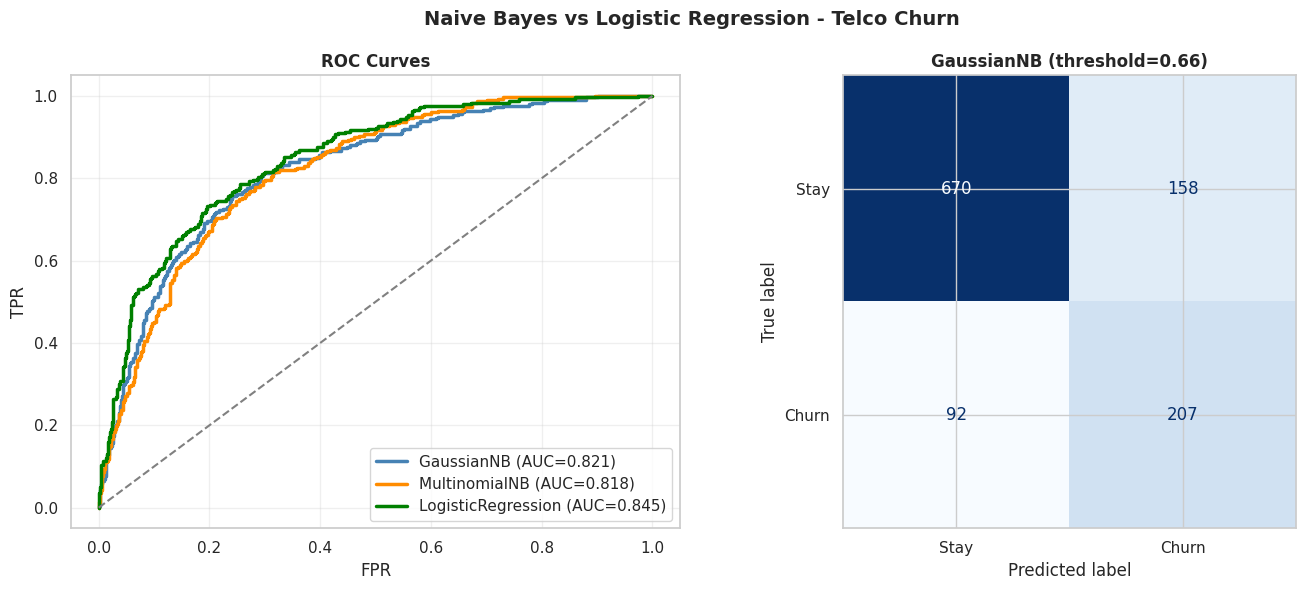

Key insight: GaussianNB gets surprisingly close to Logistic Regression
despite the naive independence assumption being violated.
Why? Because we only need correct RANKINGS of class probabilities, not exact values.


In [ ]:
# ROC curves comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_map = {'GaussianNB':'steelblue','MultinomialNB':'darkorange','LogisticRegression':'green'}
for name, m in all_results.items():
    fpr, tpr, _ = roc_curve(y_val, m['probs'])
    auc = roc_auc_score(y_val, m['probs'])
    axes[0].plot(fpr, tpr, color=colors_map[name], linewidth=2.5,
                 label=f'{name} (AUC={auc:.3f})')
axes[0].plot([0,1],[0,1],'gray',linestyle='--',linewidth=1.5)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Confusion matrix for best NB model
cm = confusion_matrix(y_val, best_preds)
ConfusionMatrixDisplay(cm, display_labels=['Stay','Churn']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'GaussianNB (threshold={best_t:.2f})', fontweight='bold')

plt.suptitle('Naive Bayes vs Logistic Regression - Telco Churn', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('Key insight: GaussianNB gets surprisingly close to Logistic Regression')
print('despite the naive independence assumption being violated.')
print('Why? Because we only need correct RANKINGS of class probabilities, not exact values.')

In [ ]:
print('=' * 60)
print('  DAY 3 NOTEBOOK 2 - FINAL RESULTS')
print('  Dataset: Telco Customer Churn (7032 customers, 19 features)')
print('  Raw data issue fixed: TotalCharges dtype (object -> float)')
print('=' * 60)
for name, m in all_results.items():
    auc = roc_auc_score(y_val, m['probs'])
    f1  = f1_score(y_val, m['preds'])
    print(f'  {name:<22}: F1={f1:.4f}  AUC={auc:.4f}')
print()
print('Key lessons:')
print('  1. Always check dtypes before modelling -- TotalCharges trap is real')
print('  2. GaussianNB: scales to billions of rows in seconds')
print('  3. MultinomialNB: needs non-negative features (use MinMaxScaler)')
print('  4. Default threshold 0.5 is not always optimal -- tune for your problem')
print('  5. NB is a strong baseline: if NB fails, the features lack signal')

  DAY 3 NOTEBOOK 2 - FINAL RESULTS
  Dataset: Telco Customer Churn (7032 customers, 19 features)
  Raw data issue fixed: TotalCharges dtype (object -> float)
  GaussianNB            : F1=0.6124  AUC=0.8206
  MultinomialNB         : F1=0.5030  AUC=0.8184
  LogisticRegression    : F1=0.6059  AUC=0.8447

Key lessons:
  1. Always check dtypes before modelling -- TotalCharges trap is real
  2. GaussianNB: scales to billions of rows in seconds
  3. MultinomialNB: needs non-negative features (use MinMaxScaler)
  4. Default threshold 0.5 is not always optimal -- tune for your problem
  5. NB is a strong baseline: if NB fails, the features lack signal


In [ ]:
print("="*80)
print("FINAL PERFORMANCE SUMMARY")
print("="*80)

print("\nGaussian Naive Bayes")
print(f"Training Time   : {gnb_training_time:.4f} sec")
print(f"Prediction Time : {gnb_prediction_time:.6f} sec")
print(f"Model Size      : {gnb_model_size:.6f} MB")

print("\nMultinomial Naive Bayes")
print(f"Training Time   : {mnb_training_time:.4f} sec")
print(f"Prediction Time : {mnb_prediction_time:.6f} sec")
print(f"Model Size      : {mnb_model_size:.6f} MB")

print("\nLogistic Regression")
print(f"Training Time   : {lr_training_time:.4f} sec")
print(f"Prediction Time : {lr_prediction_time:.6f} sec")
print(f"Model Size      : {lr_model_size:.6f} MB")

print("\nSystem Resources")
print(f"CPU Usage       : {cpu_after:.2f}%")
print(f"Memory Usage    : {memory_after:.2f} MB")

print("="*80)

FINAL PERFORMANCE SUMMARY

Gaussian Naive Bayes
Training Time   : 0.0062 sec
Prediction Time : 0.002177 sec
Model Size      : 0.001137 MB

Multinomial Naive Bayes
Training Time   : 0.0040 sec
Prediction Time : 0.001632 sec
Model Size      : 0.001148 MB

Logistic Regression
Training Time   : 0.0127 sec
Prediction Time : 0.001063 sec
Model Size      : 0.000829 MB

System Resources
CPU Usage       : 3.80%
Memory Usage    : 269.36 MB
